In [1]:
import os
os.chdir('../../../../..')

In [2]:
from typing import List

from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import numpy as np
import polars as pl
import numpy as np
import kmedoids
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.datasets import QM9Dataset
from src.non_euclidean import Grassmann
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, build_universal_matrix
from src.helper_functions import create_chemiscope_viewer

In [7]:
qm9 = QM9Dataset(limit=1000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()
frames = qm9.get_positions(invariant=False)
mol_ids = [frame.info['mol_id'] for frame in frames]
df = df.filter(pl.col("mol_id").is_in(mol_ids))

2026-04-10 14:32:31.253 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-10 14:32:31.423 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=1000, returned_rows=1000.
2026-04-10 14:32:31.423 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=1000).
2026-04-10 14:32:31.424 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).
2026-04-10 14:32:32.177 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_18733: Embedding failed.
2026-04-10 14:32:32.892 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_33751: Embedding failed.
2026-04-10 14:32:33.748 | DEBUG    | src.datasets:get_positions:1143 - Skipping qm9_51961: Embedding failed.
2026-04-10 14:32:34.676 | DEBUG    | src.datasets:get_positions:1143 - Skipping 

In [8]:
riemann = Grassmann()
distance_matrix = riemann.distance_matrix(frames, normalized=True)

Grassmann distances: 100%|██████████| 992/992 [00:54<00:00, 18.36pair/s] 


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_17921/1339866841.py:16: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='average')
Evaluating Clusters: 100%|██████████| 19/19 [00:03<00:00,  5.81it/s]


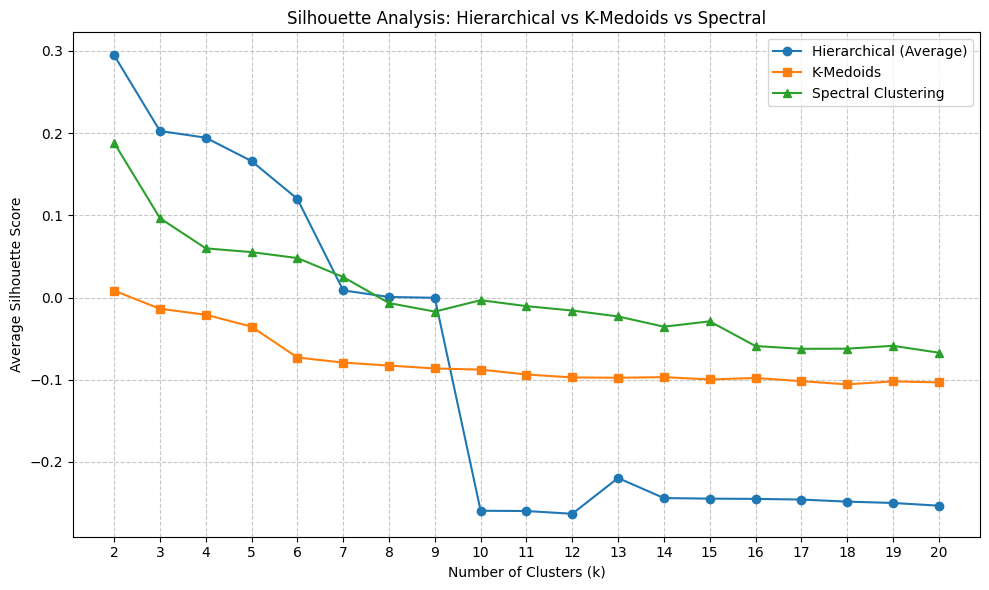

Best k for Hierarchical: 2 (Score: 0.2947)
Best k for K-Medoids:    2 (Score: 0.0085)
Best k for Spectral:     2 (Score: 0.1882)


In [9]:
# =========================================
# 1. Prepare Matrices
# =========================================
# (Assuming distance_matrix is already defined)

# Convert Distance Matrix to Affinity Matrix for Spectral Clustering
# We use the median distance as the sigma scale factor (a standard heuristic)
nonzero_dists = distance_matrix[distance_matrix > 0]
sigma = np.median(nonzero_dists) if len(nonzero_dists) > 0 else 1.0

# Gaussian Kernel: similarity decays exponentially as distance increases
affinity_matrix = np.exp(- (distance_matrix ** 2) / (2 * sigma ** 2))
np.fill_diagonal(affinity_matrix, 1.0) # An item is 100% similar to itself

# Perform hierarchical clustering using the precomputed distance matrix
linkage_matrix = linkage(distance_matrix, method='average')

# =========================================
# 2. Evaluate Clusters
# =========================================
hierarchical_scores = []
kmedoids_scores = []
spectral_scores = []

k_range = range(2, 21)  # Test k from 2 to 20

for k in tqdm(k_range, desc="Evaluating Clusters"):
    # --- 1. Hierarchical Clustering ---
    labels_hier = fcluster(linkage_matrix, k, criterion='maxclust')
    sil_hier = silhouette_score(distance_matrix, labels_hier, metric='precomputed')
    hierarchical_scores.append(sil_hier)

    # --- 2. K-Medoids Clustering ---
    km_model = kmedoids.KMedoids(
        n_clusters=k, 
        metric='precomputed', 
        random_state=42
    )
    labels_km = km_model.fit_predict(distance_matrix)
    sil_km = silhouette_score(distance_matrix, labels_km, metric='precomputed')
    kmedoids_scores.append(sil_km)

    # --- 3. Spectral Clustering ---
    # NOTE: We FIT on the affinity matrix, but EVALUATE on the distance matrix!
    spectral_model = SpectralClustering(
        n_clusters=k,
        affinity='precomputed',
        assign_labels='kmeans', # standard method to assign labels after eigenvalue decomposition
        random_state=42
    )
    labels_spec = spectral_model.fit_predict(affinity_matrix)
    
    # We still use the original distance matrix to calculate Silhouette!
    sil_spec = silhouette_score(distance_matrix, labels_spec, metric='precomputed')
    spectral_scores.append(sil_spec)

# =========================================
# 3. Plotting
# =========================================
plt.figure(figsize=(10, 6))
plt.plot(k_range, hierarchical_scores, marker='o', label='Hierarchical (Average)')
plt.plot(k_range, kmedoids_scores, marker='s', label='K-Medoids')
plt.plot(k_range, spectral_scores, marker='^', label='Spectral Clustering')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Analysis: Hierarchical vs K-Medoids vs Spectral')
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================
# 4. Results
# =========================================
best_k_hier = k_range[np.argmax(hierarchical_scores)]
best_k_km = k_range[np.argmax(kmedoids_scores)]
best_k_spec = k_range[np.argmax(spectral_scores)]

print(f"Best k for Hierarchical: {best_k_hier} (Score: {max(hierarchical_scores):.4f})")
print(f"Best k for K-Medoids:    {best_k_km} (Score: {max(kmedoids_scores):.4f})")
print(f"Best k for Spectral:     {best_k_spec} (Score: {max(spectral_scores):.4f})")

In [12]:
best_k = 6
labels = fcluster(linkage_matrix, best_k, criterion='maxclust')
df = df.with_columns(pl.Series("cluster_label", labels))
print(np.unique(labels, return_counts=True))

(array([1, 2, 3, 4, 5, 6], dtype=int32), array([887,  17,  11,  63,  13,   1]))


In [16]:
create_chemiscope_viewer(df, distance_matrix, labels, reduction_method="MDS")

Running MDS dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_MDS_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_MDS_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…